
Epoch 1
Input: [[1 1]], Target: [-1], Output: [[0.6]], Error: [[-1.6]]
Input: [[ 1 -1]], Target: [1], Output: [[-0.12]], Error: [[1.12]]
Input: [[-1  1]], Target: [-1], Output: [[-0.344]], Error: [[-0.656]]
Input: [[-1 -1]], Target: [-1], Output: [[0.2128]], Error: [[-1.2128]]

Epoch 2
Input: [[1 1]], Target: [-1], Output: [[-0.02464]], Error: [[-0.97536]]
Input: [[ 1 -1]], Target: [1], Output: [[0.245568]], Error: [[0.754432]]
Input: [[-1  1]], Target: [-1], Output: [[-1.3261184]], Error: [[0.3261184]]
Input: [[-1 -1]], Target: [-1], Output: [[-0.10369792]], Error: [[-0.89630208]]

Final Weights: [[ 0.54761114]
 [-0.3341143 ]]
Final Bias: [[-0.42798234]]


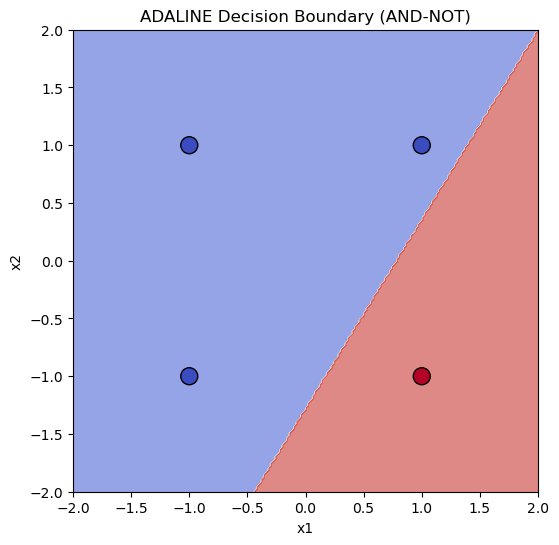

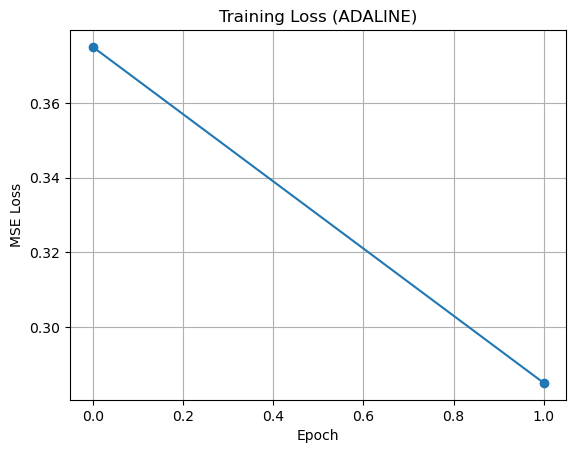

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Bipolar inputs (AND-NOT function)
X = np.array([
    [1, 1],
    [1, -1],
    [-1, 1],
    [-1, -1]
])

# Target output
y = np.array([[-1], [1], [-1], [-1]])

# Given parameters
w = np.array([[0.2], [0.2]])   # weights
b = 0.2                        # bias
alpha = 0.2                    # learning rate
epochs = 2

loss_history = []

# ADALINE Training
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}")
    
    for i in range(len(X)):
        xi = X[i].reshape(1,-1)
        target = y[i]

        # Net input
        net = np.dot(xi, w) + b
        
        # Linear output (NO sigmoid)
        output = net
        
        # Error
        error = target - output
        
        # Update weights
        w = w + alpha * xi.T * error
        b = b + alpha * error
        
        print(f"Input: {xi}, Target: {target}, Output: {output}, Error: {error}")

    # Compute loss after epoch
    net_all = np.dot(X, w) + b
    loss = np.mean((y - net_all)**2)
    loss_history.append(loss)

print("\nFinal Weights:", w)
print("Final Bias:", b)

# -------- Visualization --------

# Decision boundary
x_min, x_max = -2, 2
y_min, y_max = -2, 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = np.dot(grid, w) + b
Z = np.sign(Z)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.6, cmap="coolwarm")

# Plot data points
plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap="coolwarm", s=150, edgecolors='k')

plt.title("ADALINE Decision Boundary (AND-NOT)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# -------- Loss Graph --------

plt.plot(loss_history, marker='o')
plt.title("Training Loss (ADALINE)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# ADALINE Network (AND-NOT Function)

This implementation uses ADALINE (Adaptive Linear Neuron) to learn the AND-NOT function with bipolar inputs.

---

## Bipolar Inputs

| x1 | x2 | Target |
|----|----|--------|
| 1  | 1  | -1     |
| 1  | -1 | 1      |
| -1 | 1  | -1     |
| -1 | -1 | -1     |

---

## ADALINE Model

$$
y = w \cdot x + b
$$

---

## Weight Update Rule

$$
w = w + \alpha (t - y)x
$$

$$
b = b + \alpha (t - y)
$$

---

## Loss Function

$$
L = \frac{1}{n} \sum (t - y)^2
$$